In [177]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [178]:
df = pd.read_csv('placement.csv')

In [179]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in LPA)')

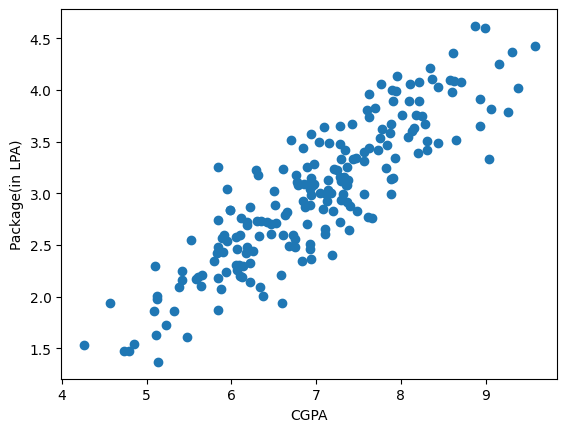

In [180]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in LPA)')

In [181]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [182]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [183]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [184]:
from sklearn.linear_model import LinearRegression

In [185]:
lr = LinearRegression()

In [186]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0, 0.5, 'Package(in LPA)')

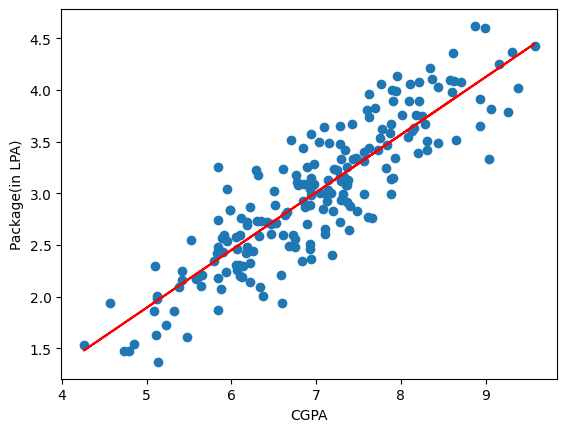

In [187]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in LPA)')

In [188]:
# Now we will be calculating the metrics for our model

In [189]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [190]:
y_pred = lr.predict(X_test)

In [191]:
y_test.values 

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [192]:
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.3f}")

Mean Absolute Error: 0.288


In [193]:
print(f"Mean Squared Error (Not in LPA): {mean_squared_error(y_test, y_pred):.3f}")

Mean Squared Error (Not in LPA): 0.121


In [194]:
print(f"Root Mean Squared Error (in LPA): {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

Root Mean Squared Error (in LPA): 0.348


In [195]:
print(f"R^2 Score: {r2_score(y_test, y_pred):.3f}")

R^2 Score: 0.781


In [196]:
# Adjusted R2 Score
r2 = r2_score(y_test, y_pred)

In [197]:
n = X_test.shape[0]
k = 1 # number of input columns
print(n)


40


In [198]:
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - 1 - k))
print(f"Adjusted R^2 Score: {adj_r2:.3f}")

Adjusted R^2 Score: 0.775


In [199]:
# Testing with random new columns to check the effect on R2 and Adjusted R2 

In [200]:
# Example 1 (Adding an irrelevant feature)

new_df1 = df.copy()
new_df1['random1'] = np.random.random(200)

new_df1 = new_df1[['cgpa', 'random1', 'package']]
new_df1.head()

,cgpa,random1,package
0,6.89,0.147079,3.26
1,5.12,0.229376,1.98
2,7.82,0.607001,3.25
3,7.42,0.534914,3.67
4,6.94,0.991875,3.57


Text(0, 0.5, 'Package(in LPA)')

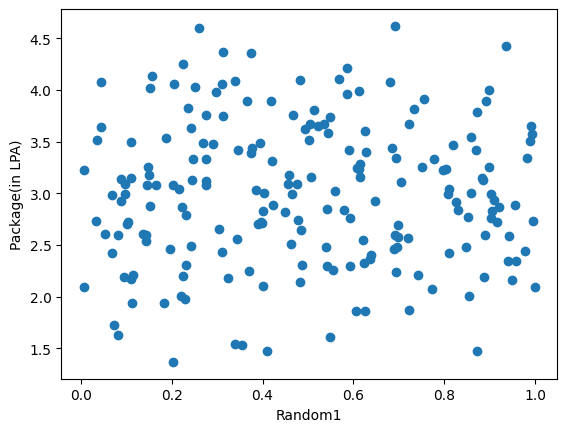

In [201]:
# random1 is not related to package, so it should not increase the R2 score much, but it will increase the Adjusted R2 score as it penalizes for adding irrelevant features.
plt.scatter(new_df1['random1'], new_df1['package'])
plt.xlabel('Random1')
plt.ylabel('Package(in LPA)')

In [202]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [203]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [204]:
lr = LinearRegression()

In [205]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [206]:
y_pred = lr.predict(X_test)

In [207]:
print(f"R2 Score: {r2_score(y_test, y_pred):.3f}")
r2 = r2_score(y_test, y_pred) # R2 score has increased as we have added an irrelevant feature, which is random1. This is because R2 does not penalize for adding irrelevant features, while Adjusted R2 does.
print(f"Adjusted R^2 Score: {adj_r2:.3f}") # Adjusted R2 score has decreased as we have added an irrelevant feature, which is random1.

R2 Score: 0.778
Adjusted R^2 Score: 0.775


In [208]:
n = X_test.shape[0]
k = 2 # number of input columns
print(n)


40


In [209]:
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - 1 - k))
print(f"Adjusted R^2 Score: {adj_r2:.3f}") # Adjusted R2 score has decreased as we have added an irrelevant feature, which is random1.

Adjusted R^2 Score: 0.766


In [210]:
# Example 2 (Adding an irrelevant feature)

In [211]:
new_df2 = df.copy()
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12, 12, 200)/10)

new_df2 = new_df2[['cgpa', 'iq', 'package']]
new_df2.sample(5)

,cgpa,iq,package
51,9.26,3.49,3.79
42,5.95,3.54,2.54
58,6.92,2.99,3.09
48,8.63,3.69,4.09
5,7.89,2.19,2.99


Text(0, 0.5, 'Package(in LPA)')

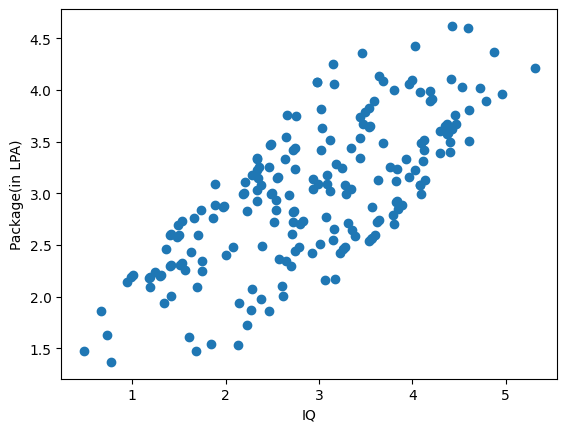

In [212]:
plt.scatter(new_df2['iq'], new_df2['package'])
plt.xlabel('IQ')
plt.ylabel('Package(in LPA)')

In [213]:
# because that one is also linear so we change that a bit

In [214]:
np.random.randint(-100, 100)

-67

In [215]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [216]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [217]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [218]:
print(f"R2 Score: {r2_score(y_test, y_pred):.3f}")
r2 = r2_score(y_test, y_pred)

R2 Score: 0.814


In [219]:
1 - ((1 - r2) * (n - 1) / (n - 1 - k))

0.8042610645271443